# State Farm Distracted Driver Detection — MobileNetV3 Transfer Learning (PyTorch)

This notebook trains a **MobileNetV3** classifier on the **State Farm Distracted Driver Detection** dataset using **PyTorch + TorchVision** transfer learning, with a **driver/subject-level split** to reduce leakage.

**Classes (Kaggle):**
- `c0`: safe driving
- `c1`: texting - right
- `c2`: talking on the phone - right
- `c3`: texting - left
- `c4`: talking on the phone - left
- `c5`: operating the radio
- `c6`: drinking
- `c7`: reaching behind
- `c8`: hair and makeup
- `c9`: talking to passenger

> Tip: This notebook is written to be robust for **RTX 50-series (Blackwell / sm_120)** by checking GPU compatibility and using a modern PyTorch build.


## 0) Install (pick ONE Torch command)

### Option A (recommended if you have “CUDA 13” / newer drivers): **CUDA 13.0 wheels (cu130)**

Run in a fresh venv/conda env:


In [1]:
# If you're in Jupyter, run this cell once (restart kernel after install).
# On Windows: you can also run these in PowerShell.

# Upgrade pip tooling
%pip install -U pip setuptools wheel

# Install PyTorch + TorchVision + TorchAudio (CUDA 13.0 wheels, cu130)
# NOTE: the '+cu130' part is important for RTX 50-series (sm_120) compatibility.
%pip install torch==2.9.1+cu130 torchvision==0.24.1+cu130 --index-url https://download.pytorch.org/whl/cu130


Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.


### Option B (very safe for RTX 50-series): **CUDA 12.8 wheels (cu128)**

If cu130 is unavailable for your Python version / OS, use cu128:


In [2]:
# If cu130 isn't available for your Python version / OS, use cu128 instead:
# %pip install -U pip setuptools wheel
# %pip install torch==2.9.1+cu128 torchvision==0.24.1+cu128 --index-url https://download.pytorch.org/whl/cu128


### Install the rest of the training stack


In [3]:
# Core scientific + training utilities (latest stable versions as of Jan 2026)
%pip install numpy==2.4.1 pandas==2.3.3 scikit-learn==1.8.0 pillow==12.1.0 tqdm==4.67.1 matplotlib==3.10.8


Note: you may need to restart the kernel to use updated packages.


## 1) Imports & config


In [4]:
import os
from pathlib import Path
import random
import math
import time
import json

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights


c:\Users\lurpd\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2) GPU / CUDA sanity check (important for RTX 5070)

This cell verifies:
- CUDA availability
- device name
- compute capability (sm version)
- torch / torchvision versions


In [5]:
def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)

    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Compute capability:", f"sm_{props.major}{props.minor}")
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))
        # Quick kernel test
        x = torch.randn(1024, 1024, device="cuda")
        y = x @ x
        print("Matmul OK. Mean:", float(y.mean()))
    else:
        print("No CUDA GPU detected by PyTorch. Training will fall back to CPU.")

cuda_sanity_check()


torch: 2.9.1+cu130
torchvision: 0.24.1+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Compute capability: sm_120
Total VRAM (GB): 11.94
Matmul OK. Mean: -0.04973173886537552


## 3) Dataset: point to your local State Farm folder

Expected Kaggle layout (after unzip):

```
state_farm/
  driver_imgs_list.csv
  imgs/
    train/
      c0/....
      c1/....
      ...
      c9/....
    test/...
```

Set `DATA_ROOT` below to your extracted dataset path.


In [6]:
# TODO: set this to YOUR dataset folder
DATA_ROOT = Path(r"../../Datasets/statefarm")  # e.g. r"D:\Datasets\state_farm"

CSV_PATH = DATA_ROOT / "driver_imgs_list.csv"
TRAIN_DIR = DATA_ROOT / "imgs" / "train"

assert CSV_PATH.exists(), f"Missing {CSV_PATH}. Did you unzip the Kaggle dataset?"
assert TRAIN_DIR.exists(), f"Missing {TRAIN_DIR}. Expected imgs/train/c0..c9"
print("Found:", CSV_PATH)
print("Found:", TRAIN_DIR)


Found: ..\..\Datasets\statefarm\driver_imgs_list.csv
Found: ..\..\Datasets\statefarm\imgs\train


## 4) Build a driver/subject-level train/val split (prevents leakage)

We split by the **`subject`** column from `driver_imgs_list.csv`.


In [7]:
df = pd.read_csv(CSV_PATH)
df.head()


,subject,classname,img
0,p012,c0,img_10206.jpg
1,p012,c0,img_27079.jpg
2,p012,c0,img_50749.jpg
3,p012,c0,img_97089.jpg
4,p012,c0,img_37741.jpg


In [8]:
# Basic sanity checks
required_cols = {"subject", "classname", "img"}
missing = required_cols - set(df.columns)
assert not missing, f"CSV missing columns: {missing}"

df["path"] = df.apply(lambda r: TRAIN_DIR / r["classname"] / r["img"], axis=1)
missing_files = (~df["path"].apply(lambda p: p.exists())).sum()
assert missing_files == 0, f"Some image paths are missing ({missing_files}). Check your folder structure."

classes = sorted(df["classname"].unique())
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

print("Classes:", classes)
print("Num images:", len(df))
print("Num subjects:", df["subject"].nunique())


Classes: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Num images: 34924
Num subjects: 20


In [9]:
# GroupShuffleSplit keeps all images for a subject either in train or val
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df["subject"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df))
print("Train subjects:", train_df["subject"].nunique(), "Val subjects:", val_df["subject"].nunique())


Train: 27872 Val: 7052
Train subjects: 16 Val subjects: 4


## 5) Transforms (MobileNetV3 defaults + augmentation)

We use the official ImageNet normalization from the MobileNetV3 weights metadata.


In [10]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import MobileNet_V3_Large_Weights

weights = MobileNet_V3_Large_Weights.DEFAULT

# Use the official preprocessing pipeline attached to the weights
preprocess = weights.transforms()

# Robustly grab mean/std + image size (works across torchvision versions)
mean = getattr(preprocess, "mean", None) or weights.meta.get("mean", [0.485, 0.456, 0.406])
std  = getattr(preprocess, "std", None)  or weights.meta.get("std",  [0.229, 0.224, 0.225])

crop_size = getattr(preprocess, "crop_size", (224, 224))
IMG_SIZE = crop_size[0] if isinstance(crop_size, (tuple, list)) else int(crop_size)

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.TrivialAugmentWide(interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

# Best practice: use the weights' own validation preprocessing
val_tfms = preprocess

print("IMG_SIZE:", IMG_SIZE)
print("mean:", mean, "std:", std)


IMG_SIZE: 224
mean: [0.485, 0.456, 0.406] std: [0.229, 0.224, 0.225]


## 6) Dataset / DataLoaders


In [11]:
class StateFarmCSVDataset(Dataset):
    def __init__(self, frame, class_to_idx, transform=None, cache_images=False):
        self.frame = frame.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.cache_images = cache_images
        self._cache = {}  # idx -> PIL.Image (RGB)

    def __len__(self):
        return len(self.frame)

    def _load_image(self, i):
        if self.cache_images and i in self._cache:
            return self._cache[i].copy()  # copy so transforms can modify safely

        img_path = self.frame.loc[i, "path"]
        im = Image.open(img_path).convert("RGB")

        if self.cache_images:
            self._cache[i] = im.copy()

        return im

    def __getitem__(self, i):
        row = self.frame.loc[i]
        y = self.class_to_idx[row["classname"]]
        im = self._load_image(i)
        x = self.transform(im) if self.transform else transforms.ToTensor()(im)
        return x, y

train_ds = StateFarmCSVDataset(train_df, class_to_idx, transform=train_tfms, cache_images=True)
val_ds   = StateFarmCSVDataset(val_df, class_to_idx, transform=val_tfms,   cache_images=True)

BATCH_SIZE = 128
NUM_WORKERS = 0  # Windows + Jupyter safest

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,          # set True later once working
    persistent_workers=False,  # MUST be False in notebooks usually
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    persistent_workers=False,
)


print("NUM_WORKERS:", NUM_WORKERS)


NUM_WORKERS: 0


In [12]:
import time
t0 = time.time()
xb, yb = next(iter(train_loader))
print("Got batch:", xb.shape, yb.shape, "in", round(time.time()-t0, 2), "sec")


Got batch: torch.Size([128, 3, 224, 224]) torch.Size([128]) in 1.02 sec


## 7) Model: MobileNetV3-Large transfer learning


In [13]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Load pretrained MobileNetV3-Large ---
weights = MobileNet_V3_Large_Weights.DEFAULT
model = mobilenet_v3_large(weights=weights)

num_classes = len(classes)

# --- Replace the last classifier layer to match State Farm's 10 classes ---
# MobileNetV3 classifier is a Sequential; the last item is the final Linear layer.
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, num_classes)

# ------------------------------------------------------------
# Freeze most of the network, unfreeze only the last few blocks
# ------------------------------------------------------------

# 1) Freeze EVERYTHING first (no gradients will be computed -> weights won't change)
for p in model.parameters():
    p.requires_grad = False

# 2) Unfreeze the classifier (we almost always want this trainable)
for p in model.classifier.parameters():
    p.requires_grad = True

# 3) Unfreeze the last N blocks of the feature extractor
# model.features is a Sequential of blocks.
# Unfreezing later blocks lets the model adapt higher-level features to your dataset.
UNFREEZE_LAST_N_BLOCKS = 10  #higher = more overfitting risk

# Convert to list so we can slice the last N blocks
feature_blocks = list(model.features.children())

# Unfreeze last N feature blocks
for block in feature_blocks[-UNFREEZE_LAST_N_BLOCKS:]:
    for p in block.parameters():
        p.requires_grad = True

# Move model to GPU/CPU
model = model.to(device)

# --- Optional performance knobs (safe defaults) ---
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

# --- Sanity print: how many parameters are trainable? ---
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

print("Unfroze last", UNFREEZE_LAST_N_BLOCKS, "feature blocks + classifier.")


Trainable params: 4,153,722 / 4,214,842 (98.55%)
Unfroze last 10 feature blocks + classifier.


## 8) Training utilities (AMP + metrics + checkpointing)


In [14]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    epochs: int = 25
    lr: float = 5e-4
    weight_decay: float = 1e-2
    label_smoothing: float = 0.02
    grad_clip: float = 1.0

    # early stopping controls
    patience: int = 8          # give it time to recover after a dip
    min_delta: float = 0.002   # require a *real* improvement, not tiny noise

    out_dir: Path = Path("./checkpoints")
    best_name: str = "mobilenetv3_statefarm_best.pt"


cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
print(cfg)


TrainConfig(epochs=25, lr=0.0005, weight_decay=0.01, label_smoothing=0.02, grad_clip=1.0, patience=8, min_delta=0.002, out_dir=WindowsPath('checkpoints'), best_name='mobilenetv3_statefarm_best.pt')


In [ ]:
criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

# Only optimize parameters that are unfrozen (requires_grad=True)
feature_params = []
head_params = []

for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if name.startswith("classifier"):
        head_params.append(p)
    else:
        feature_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": feature_params, "lr": cfg.lr * 0.2},  # smaller LR for backbone
        {"params": head_params, "lr": cfg.lr},           # bigger LR for classifier
    ],
    weight_decay=cfg.weight_decay
)



# Reduce LR when val_f1 stops improving (stable for driver-split training)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",    # maximize val_f1
    factor=0.5,    #Decrease LR
    patience=2,    # wait 2 epochs before reducing
    min_lr=1e-6,
)

def get_lrs(opt):
    return [pg["lr"] for pg in opt.param_groups]

# AMP scaler (newer torch prefers torch.amp.GradScaler)
scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

def run_one_epoch(model, loader, train: bool):
    model.train(train)
    all_y = []
    all_p = []
    total_loss = 0.0

    pbar = tqdm(loader, desc="train" if train else "val", leave=False)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()

                if cfg.grad_clip is not None and cfg.grad_clip > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

                scaler.step(optimizer)
                scaler.update()

        total_loss += float(loss.item()) * xb.size(0)

        preds = logits.argmax(dim=1)
        all_y.append(yb.detach().cpu().numpy())
        all_p.append(preds.detach().cpu().numpy())

        pbar.set_postfix(loss=float(loss.item()))

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return avg_loss, acc, f1

def save_checkpoint(path: Path, model):
    torch.save(model.state_dict(), path)

    meta = {
        "classes": classes,
        "class_to_idx": class_to_idx,
        "img_size": IMG_SIZE,
        "mean": mean,
        "std": std,
        "torch_version": str(torch.__version__), 
    }
    with open(path.with_suffix(".json"), "w") as f:
        json.dump(meta, f, indent=2)


best_val_f1 = -1.0
best_epoch = -1
bad_epochs = 0

history = []


## 9) Train


In [16]:
for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()
    train_loss, train_acc, train_f1 = run_one_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_one_epoch(model, val_loader, train=False)

    before = get_lrs(optimizer)
    scheduler.step(val_f1) 
    after = get_lrs(optimizer)

    if after != before:
        print("🔻 LR reduced:", before, "->", after)


    dt = time.time() - t0
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "seconds": dt,
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
        f"{dt:.1f}s"
    )

    # Checkpoint
    # Save best by VAL F1 (macro)
    if val_f1 > best_val_f1 + cfg.min_delta:
        best_val_f1 = val_f1
        best_epoch = epoch
        bad_epochs = 0
        ckpt_path = cfg.out_dir / cfg.best_name
        save_checkpoint(ckpt_path, model)
        print("  ✅ saved best (val_f1):", ckpt_path)
    else:
        bad_epochs += 1
        if bad_epochs >= cfg.patience:
            print(f"  🛑 early stopping (no val_f1 improvement for {cfg.patience} epochs)")
            break


print("Best epoch:", best_epoch, "Best val f1:", best_val_f1)


Epoch 01/25 | train loss 0.5736 acc 0.8605 f1 0.8601 | val loss 1.1684 acc 0.5973 f1 0.6190 | 297.8s
  ✅ saved best (val_f1): checkpoints\mobilenetv3_statefarm_best.pt


Epoch 02/25 | train loss 0.2236 acc 0.9766 f1 0.9765 | val loss 1.0047 acc 0.6889 f1 0.6870 | 56.4s
  ✅ saved best (val_f1): checkpoints\mobilenetv3_statefarm_best.pt


Epoch 03/25 | train loss 0.1869 acc 0.9869 f1 0.9869 | val loss 0.9595 acc 0.7181 f1 0.7225 | 55.2s
  ✅ saved best (val_f1): checkpoints\mobilenetv3_statefarm_best.pt


Epoch 04/25 | train loss 0.1749 acc 0.9900 f1 0.9899 | val loss 1.0042 acc 0.6721 f1 0.6753 | 55.0s


Epoch 05/25 | train loss 0.1686 acc 0.9911 f1 0.9910 | val loss 0.8828 acc 0.7439 f1 0.7351 | 54.8s
  ✅ saved best (val_f1): checkpoints\mobilenetv3_statefarm_best.pt


...

Epoch 21/25 | train loss 0.1404 acc 0.9978 f1 0.9979 | val loss 0.8517 acc 0.7348 f1 0.7480 | 52.9s


Epoch 22/25 | train loss 0.1419 acc 0.9972 f1 0.9972 | val loss 0.8650 acc 0.7374 f1 0.7466 | 52.5s


Epoch 23/25 | train loss 0.1388 acc 0.9982 f1 0.9982 | val loss 0.7910 acc 0.7833 f1 0.7850 | 53.2s
  ✅ saved best (val_f1): checkpoints\mobilenetv3_statefarm_best.pt


Epoch 24/25 | train loss 0.1392 acc 0.9979 f1 0.9979 | val loss 0.8678 acc 0.7459 f1 0.7514 | 52.7s


Epoch 25/25 | train loss 0.1395 acc 0.9977 f1 0.9977 | val loss 0.8829 acc 0.7354 f1 0.7431 | 52.9s
Best epoch: 23 Best val f1: 0.7849998886672348


## 10) Plot learning curves


In [17]:
hist = pd.DataFrame(history)
hist


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,seconds,lr
0,1,0.573634,0.860469,0.860083,1.168372,0.597277,0.619009,297.798608,0.000100
1,2,0.223645,0.976571,0.976524,1.004683,0.688883,0.686988,56.419073,0.000100
2,3,0.186881,0.986940,0.986915,0.959484,0.718094,0.722521,55.200575,0.000100
3,4,0.174869,0.989954,0.989947,1.004243,0.672150,0.675263,55.020970,0.000100
4,5,0.168642,0.991066,0.991043,0.882780,0.743902,0.735092,54.836481,0.000100
5,6,0.161368,0.993147,0.993113,0.930382,0.703347,0.707855,55.123169,0.000100
6,7,0.157949,0.993829,0.993688,0.916927,0.722915,0.720361,55.001226,0.000100
7,8,0.155787,0.994439,0.994407,0.931355,0.721214,0.716064,55.390090,0.000075
8,9,0.152703,0.994618,0.994571,0.880921,0.743619,0.738269,55.074393,0.000075
9,10,0.147085,0.996663,0.996622,0.944444,0.719229,0.723061,54.878463,0.000075


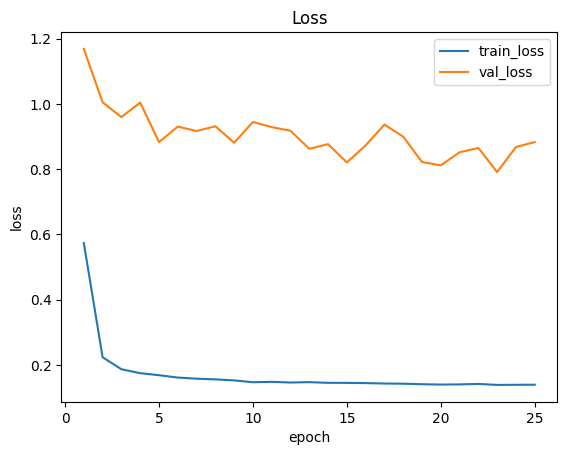

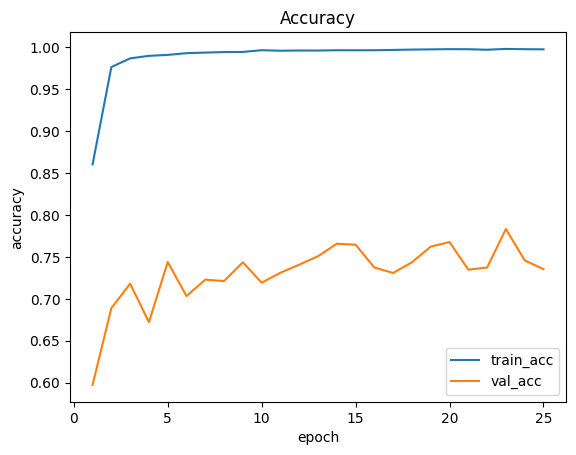

In [18]:
plt.figure()
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.show()


## 11) Detailed validation report


In [ ]:
# Reload best checkpoint (OLD payload format)
ckpt_path = cfg.out_dir / cfg.best_name

# Load full payload (safe since you created it)
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

classes_ckpt = ckpt["classes"]
class_to_idx_ckpt = ckpt["class_to_idx"]

best_model = mobilenet_v3_large(weights=weights)
best_model.classifier[-1] = nn.Linear(best_model.classifier[-1].in_features, len(classes_ckpt))
best_model.load_state_dict(ckpt["model_state"])
best_model = best_model.to(device)
best_model.eval()

# Evaluate
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc="val eval"):
        xb = xb.to(device, non_blocking=True)
        logits = best_model(xb)
        preds = logits.argmax(1).cpu().numpy()
        y_pred_all.append(preds)
        y_true_all.append(yb.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Macro F1:", f1_score(y_true_all, y_pred_all, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=classes_ckpt))


FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints\\mobilenetv3_statefarm_best.json'

In [ ]:
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.xlabel("Pred")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 12) Quick inference on a few images


In [ ]:
# Grab a few validation samples
def denorm(x, mean, std):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    return (x * std) + mean

best_model.eval()
samples = [val_ds[i] for i in np.random.choice(len(val_ds), size=8, replace=False)]
xb = torch.stack([s[0] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    logits = best_model(xb)
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(1).cpu().numpy()

# Show
plt.figure(figsize=(12, 6))
for i in range(len(samples)):
    ax = plt.subplot(2, 4, i+1)
    img = denorm(samples[i][0].cpu(), mean, std).clamp(0,1)
    ax.imshow(img.permute(1,2,0))
    ax.axis("off")
    ax.set_title(f"T:{idx_to_class[yb[i]]}\nP:{idx_to_class[pred[i]]}")
plt.tight_layout()
plt.show()


## 13) Export (optional): TorchScript

Useful if you want to deploy the model later (e.g., to a desktop app). For mobile/on-device, you might prefer ONNX or ExecuTorch.


In [ ]:
EXPORT = False

if EXPORT:
    best_model.eval()
    example = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    traced = torch.jit.trace(best_model, example)
    out_path = cfg.out_dir / "mobilenetv3_statefarm_traced.pt"
    traced.save(out_path)
    print("Saved:", out_path)


## Notes / common issues

- If you see: **“CUDA capability sm_120 is not compatible”**, you installed a PyTorch build that doesn't include Blackwell kernels. Reinstall Torch from **cu128** or **cu130**.
- If `torch.cuda.is_available()` is `False` on Windows, verify:
  - NVIDIA driver is installed and `nvidia-smi` works
  - your venv doesn't accidentally have CPU-only `torch` from PyPI
